# Experimento GP — KernelSynth: ¿Puede Chronos Ganar?

**Hipótesis:** Chronos fue entrenado con datos sintéticos generados por Gaussian Processes con kernels compuestos (*KernelSynth*, Ansari et al. 2024). Para este tipo de serie, la covarianza del GP **no tiene representación ARMA de orden finito**, por lo que cualquier modelo clásico con parametrización fija especifica mal el proceso. Chronos, en cambio, puede reconocer y extrapolar el patrón sin estimación paramétrica.  

**DGP:** `GPKernelSynthDGP` — muestras de GP con kernel RBF, Periódico, o su combinación  
**Kernels:**  
- **RBF:** $k(t,t') = \sigma^2 \exp\!\left(-\tfrac{|t-t'|^2}{2\ell^2}\right)$ — tendencia suave  
- **Periódico:** $k(t,t') = \sigma^2 \exp\!\left(-\tfrac{2\sin^2(\pi|t-t'|/p)}{\ell^2}\right)$ — estructura estacional  
- **RBF + Periódico:** combinación (más cercano al KernelSynth del paper)  

**Setup:** T ∈ {50, 200} | H = 24 | R = 500 | Semilla = 3649  
**Resultados:** guardados en `results/gp/` — si existen se cargan sin re-simular

---

In [1]:
import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

from mectesis.dgp import GPKernelSynthDGP
from mectesis.models import (
    ARIMAModel, ChronosModel,
    SARIMAModel, ETSModel, ThetaModel,
)
from mectesis.simulation import MonteCarloEngine

SEED    = 3649
H       = 24
R_LIST  = [500]
T_LIST  = [50, 200]
RESULTS = Path("results/gp")
RESULTS.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
pd.set_option("display.float_format", "{:.4f}".format)

print("Cargando Chronos-2 (puede tardar ~30 s)...")
chronos = ChronosModel(device="cpu")
print("Chronos-2 listo.")

Cargando Chronos-2 (puede tardar ~30 s)...
Chronos-2 listo.


In [2]:
def _cache_path(exp_id: str, T: int, R: int) -> Path:
    return RESULTS / f"exp_{exp_id.replace('.', '_')}_T{T}_R{R}.csv"


def _save_results(results: dict, path: Path):
    frames = []
    for mname, df in results.items():
        tmp = df.copy()
        tmp.insert(0, 'model', mname)
        frames.append(tmp)
    pd.concat(frames, ignore_index=True).to_csv(path, index=False)


def _load_results(path: Path) -> dict:
    df = pd.read_csv(path)
    return {
        mname: grp.drop(columns='model').reset_index(drop=True)
        for mname, grp in df.groupby('model', sort=False)
    }


def run_exp(dgp, make_models_fn, dgp_params, exp_id,
            T_list=T_LIST, R_list=R_LIST, H=H, seed=SEED):
    n_runs = len(T_list) * len(R_list)
    combos = ', '.join(f'(T={t}, R={r})' for t in T_list for r in R_list)
    print(f'Exp {exp_id}: {n_runs} ejecución(es) → {combos}')
    all_results = {}
    for T in T_list:
        for R in R_list:
            cache = _cache_path(exp_id, T, R)
            if cache.exists():
                print(f'  T={T}, R={R}: cargando {cache.name} ...')
                all_results[(T, R)] = _load_results(cache)
                continue
            print(f'  T={T}, R={R}: simulando ...', end=' ', flush=True)
            dgp.rng = np.random.default_rng(seed)
            models = make_models_fn(T)
            engine = MonteCarloEngine(dgp, models, seed=seed)
            t0 = time.time()
            results = engine.run_monte_carlo(R, T, H, dgp_params, verbose=False)
            elapsed = time.time() - t0
            print(f'OK ({elapsed:.0f}s)')
            _save_results(results, cache)
            all_results[(T, R)] = results
    return all_results


def compute_blocks(results_TR: dict):
    out = {}
    for mname, df in results_TR.items():
        df_h = df[df["horizon"] != "avg_all"].copy()
        df_h["horizon"] = pd.to_numeric(df_h["horizon"], errors="coerce")
        out[mname] = {
            "h=1-12":  df_h[df_h["horizon"] <= 12].mean(numeric_only=True),
            "h=13-24": df_h[df_h["horizon"] >= 13].mean(numeric_only=True),
        }
    return out


def results_table(all_results):
    seen: dict = {}
    for res_TR in all_results.values():
        for df in res_TR.values():
            for c in df.columns:
                if c not in ('horizon',) and df[c].dtype != object:
                    seen[c] = True
    numeric_cols = list(seen)
    rows = []
    for (T, R), res_TR in sorted(all_results.items()):
        for mname, blk in compute_blocks(res_TR).items():
            for bname, m in blk.items():
                row = {'T': T, 'R': R, 'Modelo': mname, 'Bloque': bname}
                for col in numeric_cols:
                    if col in m.index:
                        row[col] = round(float(m[col]), 4)
                rows.append(row)
    df = pd.DataFrame(rows).set_index(['T', 'R', 'Modelo', 'Bloque'])
    grad_cols = [c for c in ['rmse', 'mae'] if c in df.columns]
    display(df.style.format(precision=4)
              .background_gradient(subset=grad_cols, cmap='YlOrRd'))


def plot_rep(dgp, make_models_fn, dgp_params,
             T=200, H=H, seed=SEED, title=''):
    dgp_r = dgp.__class__(seed=seed)
    y = dgp_r.simulate(T=T, **dgp_params)
    y_train, y_test = y[:-H], y[-H:]
    models = make_models_fn(T)
    fig, ax = plt.subplots(figsize=(13, 4))
    x_tr = np.arange(len(y_train))
    x_te = np.arange(len(y_train), T)
    ax.plot(x_tr, y_train, color="steelblue", lw=1.4, alpha=0.85, label="Histórico")
    ax.plot(x_te, y_test, "k--", lw=1.5, label="Observado (test)")
    ax.axvline(len(y_train) - 0.5, color='gray', ls=':', lw=1, alpha=0.6)
    palette = ['crimson', 'darkorange', 'seagreen', 'purple', 'teal', 'olive']
    for i, m in enumerate(models):
        m.fit(y_train)
        y_hat = m.forecast(H)
        ax.plot(x_te, y_hat, color=palette[i % len(palette)],
                lw=1.5, marker='o', ms=3, label=m.name)
        if m.supports_intervals:
            lo, hi = m.forecast_intervals(H, level=0.95)
            ax.fill_between(x_te, lo, hi,
                            color=palette[i % len(palette)],
                            alpha=0.12, label='_nolegend_')
    ax.set(title=title, xlabel='t', ylabel='$Y_t$')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()


def plot_metrics(all_results, title='', metrics=('rmse', 'bias')):
    keys = sorted(all_results.keys())
    fig, axes = plt.subplots(
        len(metrics), len(keys),
        figsize=(7 * len(keys), 3.5 * len(metrics)),
        squeeze=False,
    )
    palette = ['crimson', 'darkorange', 'seagreen', 'purple', 'teal', 'steelblue']
    for col, (T, R) in enumerate(keys):
        for row, metric in enumerate(metrics):
            ax = axes[row][col]
            for i, (mname, df) in enumerate(all_results[(T, R)].items()):
                df_h = df[df["horizon"] != "avg_all"].copy()
                df_h["horizon"] = pd.to_numeric(df_h["horizon"], errors="coerce")
                if metric not in df_h.columns:
                    continue
                ax.plot(df_h['horizon'], df_h[metric],
                        label=mname, color=palette[i % len(palette)], lw=1.5)
            ax.axvline(12.5, color='gray', ls=':', lw=0.8, alpha=0.5)
            ax.set(
                title=f'T={T}, R={R} — {metric.upper()}',
                xlabel='Horizonte h',
                ylabel=metric.upper(),
            )
            ax.legend(fontsize=8)
    fig.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()

---
## Experimento GP.1

**DGP:** GP — kernel RBF (tendencia suave no lineal)  
$$f \sim \mathcal{GP}\!\left(0,\; \sigma^2 e^{-|t-t'|^2/2\ell^2}\right), \quad y_t = f(t) + \varepsilon_t$$
con $\ell=30$, $\sigma=1$, $\sigma_\varepsilon=0.3$  

**Modelos clásicos:** ARIMA(1,1,1), ETS(A,A,N)  
**Hipótesis:** La tendencia suave no tiene representación ARMA finita — Chronos reconoce el patrón por su entrenamiento en GPs.

In [3]:
dgp_GP_1         = GPKernelSynthDGP(seed=SEED)
make_models_GP_1 = lambda T: [ARIMAModel((1,1,1)), ETSModel(trend='add'), chronos]
dgp_params_GP_1  = {'kernel': 'rbf', 'lengthscale_rbf': 30.0, 'sigma_rbf': 1.0, 'noise_std': 0.3}

results_GP_1 = run_exp(
    dgp_GP_1, make_models_GP_1, dgp_params_GP_1,
    exp_id='GP.1',
)

Exp GP.1: 2 ejecución(es) → (T=50, R=500), (T=200, R=500)
  T=50, R=500: simulando ... 

c:\Users\HP\OneDrive\Escritorio\David Guzzi\Github\MECTESIS\.venv_mectesis\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\HP\OneDrive\Escritorio\David Guzzi\Github\MECTESIS\.venv_mectesis\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\HP\OneDrive\Escritorio\David Guzzi\Github\MECTESIS\.venv_mectesis\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
c:\Users\HP\OneDrive\Escritorio\David Guzzi\Github\MECTESIS\.venv_mectesis\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.w

OK (298s)
  T=200, R=500: simulando ... OK (406s)


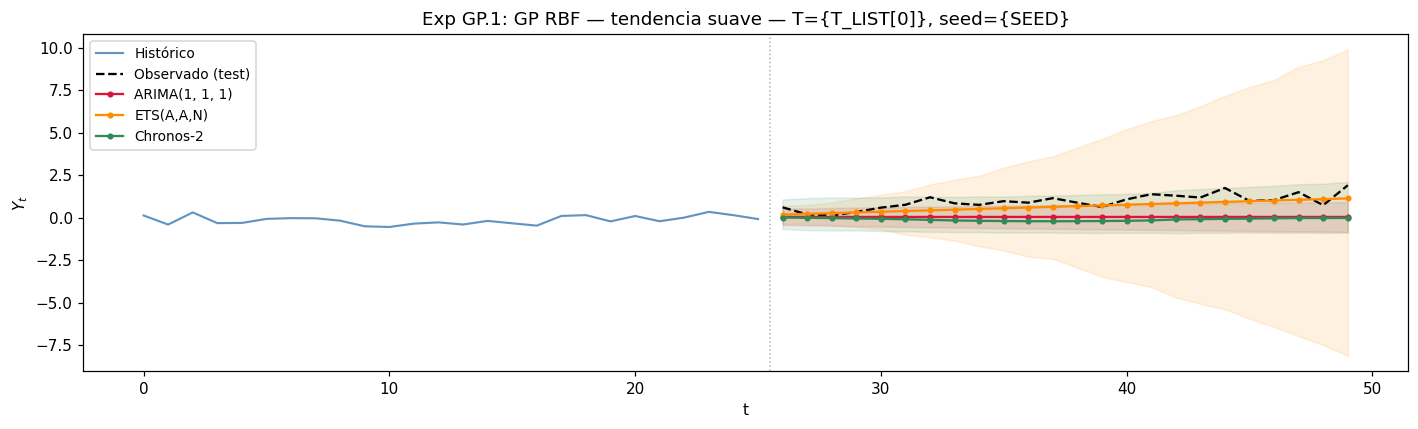

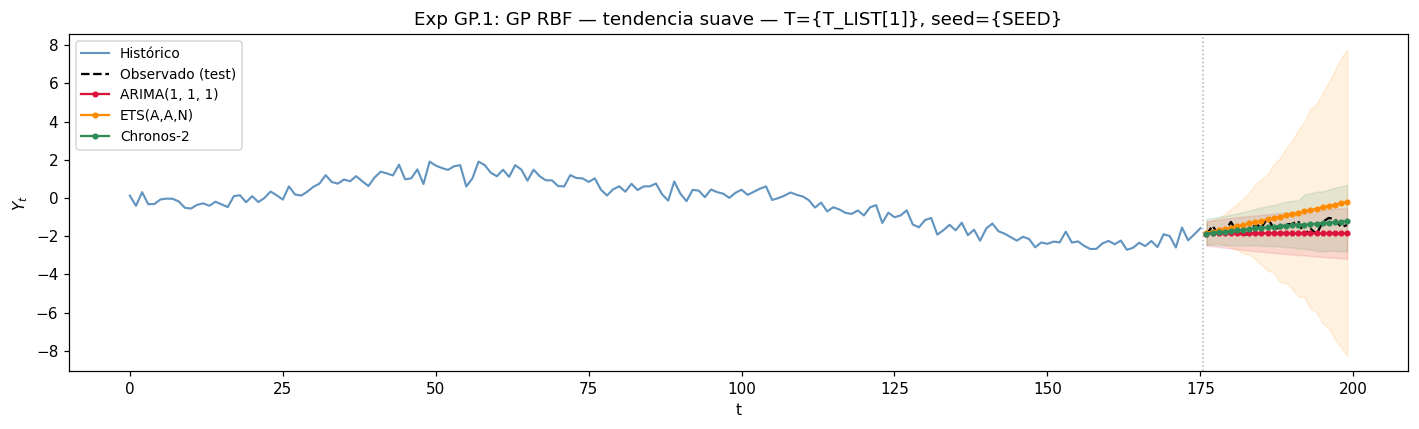

Tabla de métricas — Exp GP.1


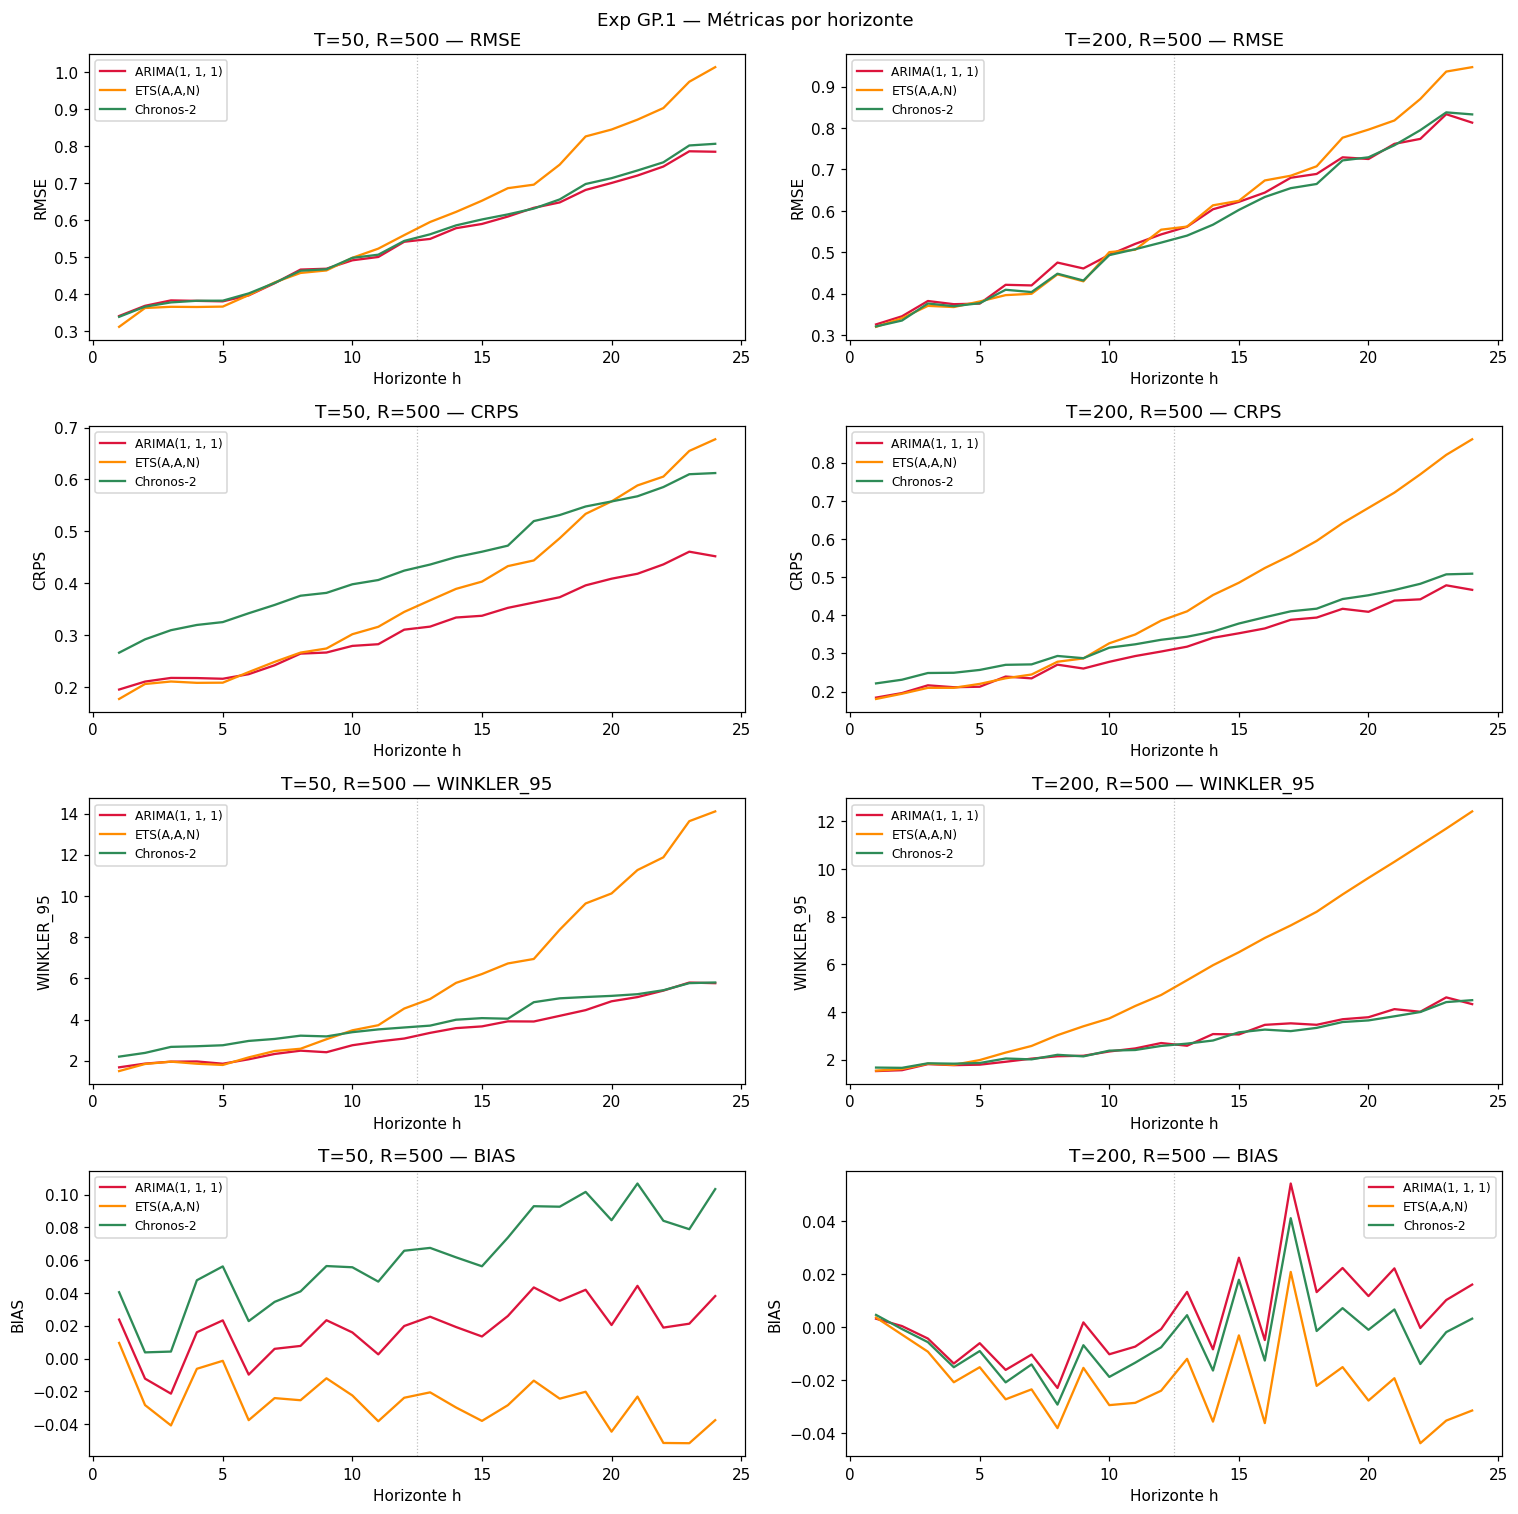

In [4]:
plot_rep(
    dgp_GP_1, make_models_GP_1, dgp_params_GP_1,
    T=T_LIST[0],
    title='Exp GP.1: GP RBF — tendencia suave — T={T_LIST[0]}, seed={SEED}'
)
plot_rep(
    dgp_GP_1, make_models_GP_1, dgp_params_GP_1,
    T=T_LIST[1],
    title='Exp GP.1: GP RBF — tendencia suave — T={T_LIST[1]}, seed={SEED}'
)
print("Tabla de métricas — Exp GP.1")
results_table(results_GP_1)
plot_metrics(
    results_GP_1,
    title="Exp GP.1 — Métricas por horizonte",
    metrics=("rmse", "crps", "winkler_95", "bias")
)

---
## Experimento GP.2

**DGP:** GP — kernel Periódico (s=12)  
$$f \sim \mathcal{GP}\!\left(0,\; \sigma^2 e^{-2\sin^2(\pi|t-t'|/12)/\ell^2}\right), \quad y_t = f(t) + \varepsilon_t$$
con $p=12$, $\ell=1$, $\sigma=1$, $\sigma_\varepsilon=0.3$  

**Modelos clásicos:** SARIMA(1,0,1)(1,0,1)_12, ETS con estacionalidad  
**Hipótesis:** El kernel periódico genera estructura estacional suave que el SARIMA aproxima con parámetros lineales — Chronos la captura directamente.

In [5]:
dgp_GP_2         = GPKernelSynthDGP(seed=SEED)
make_models_GP_2 = lambda T: [SARIMAModel((1,0,1),(1,0,1,12)), ETSModel(trend=None, seasonal='add', seasonal_periods=12), chronos]
dgp_params_GP_2  = {'kernel': 'periodic', 'period': 12.0, 'lengthscale_per': 1.0, 'sigma_per': 1.0, 'noise_std': 0.3}

results_GP_2 = run_exp(
    dgp_GP_2, make_models_GP_2, dgp_params_GP_2,
    exp_id='GP.2',
)

Exp GP.2: 2 ejecución(es) → (T=50, R=500), (T=200, R=500)
  T=50, R=500: simulando ... OK (379s)
  T=200, R=500: simulando ... OK (579s)


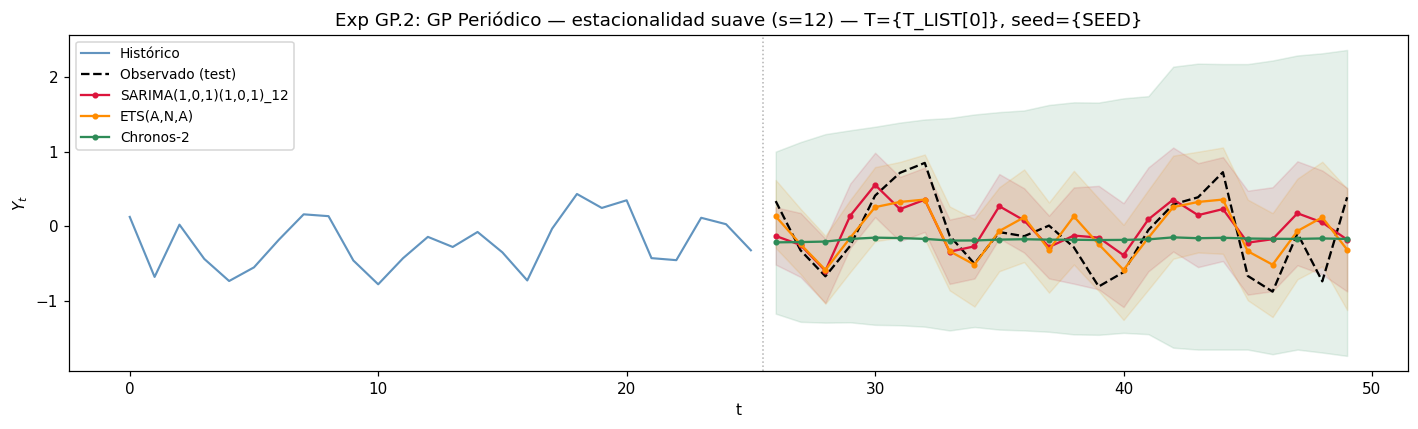

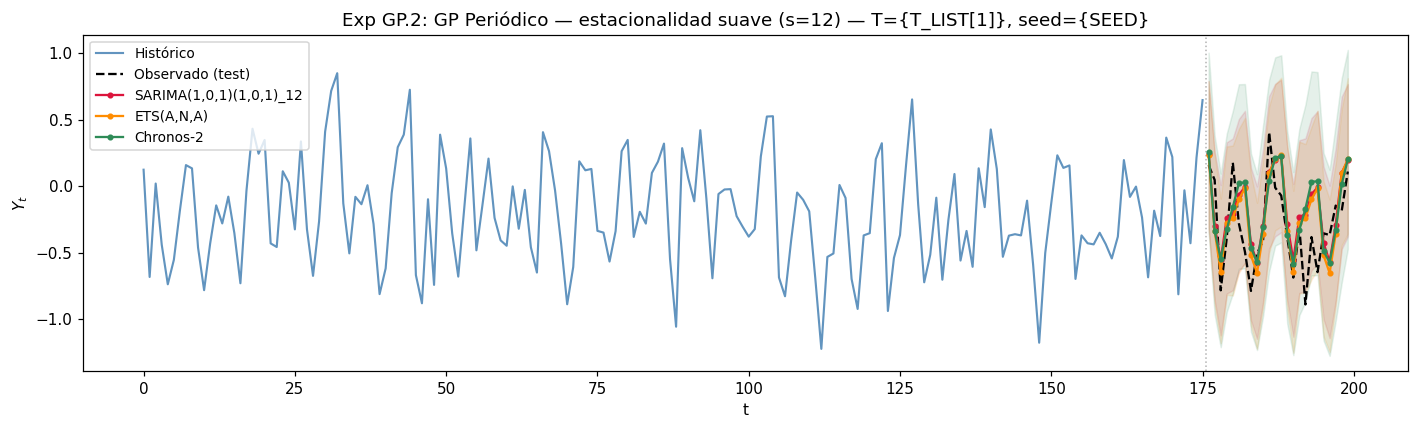

Tabla de métricas — Exp GP.2


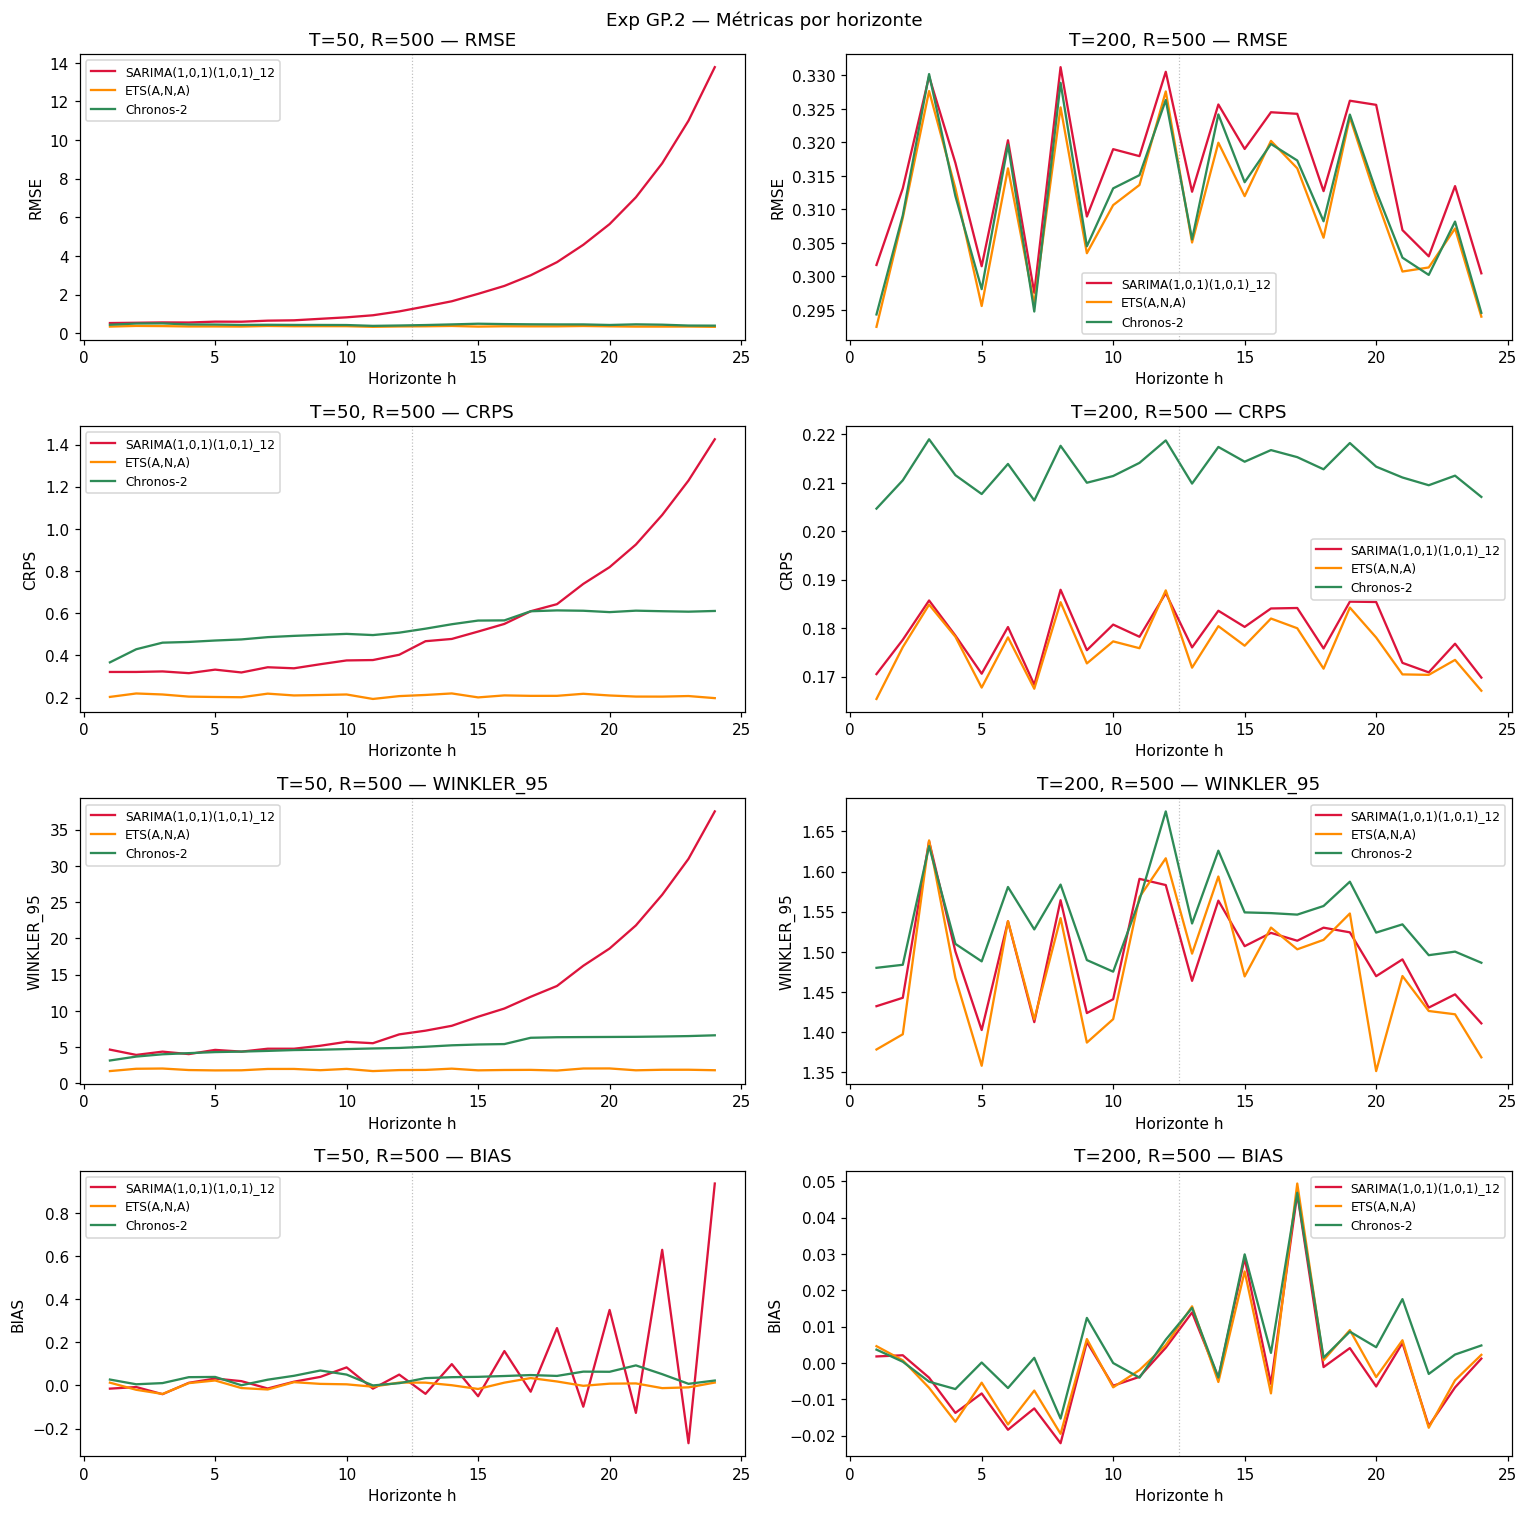

In [6]:
plot_rep(
    dgp_GP_2, make_models_GP_2, dgp_params_GP_2,
    T=T_LIST[0],
    title='Exp GP.2: GP Periódico — estacionalidad suave (s=12) — T={T_LIST[0]}, seed={SEED}'
)
plot_rep(
    dgp_GP_2, make_models_GP_2, dgp_params_GP_2,
    T=T_LIST[1],
    title='Exp GP.2: GP Periódico — estacionalidad suave (s=12) — T={T_LIST[1]}, seed={SEED}'
)
print("Tabla de métricas — Exp GP.2")
results_table(results_GP_2)
plot_metrics(
    results_GP_2,
    title="Exp GP.2 — Métricas por horizonte",
    metrics=("rmse", "crps", "winkler_95", "bias")
)

---
## Experimento GP.3

**DGP:** GP — kernel RBF + Periódico (**KernelSynth completo**)  
$$K = \sigma_{\text{rbf}}^2 e^{-|t-t'|^2/2\ell_{\text{rbf}}^2} + \sigma_{\text{per}}^2 e^{-2\sin^2(\pi|t-t'|/12)/\ell_{\text{per}}^2} + \sigma_\varepsilon^2 I$$
con $\ell_{\text{rbf}}=30$, $\sigma_{\text{rbf}}=1$, $p=12$, $\sigma_{\text{per}}=0.8$, $\sigma_\varepsilon=0.3$  

**Modelos clásicos:** SARIMA(1,1,1)(1,0,1)_12, ETS(A,A,A), Theta  
**Hipótesis:** Este DGP replica directamente el proceso de generación sintética de KernelSynth usado en el entrenamiento de Chronos. La ventaja de Chronos debería ser máxima aquí.

In [7]:
dgp_GP_3         = GPKernelSynthDGP(seed=SEED)
make_models_GP_3 = lambda T: [SARIMAModel((1,1,1),(1,0,1,12)), ETSModel(trend='add', seasonal='add', seasonal_periods=12), ThetaModel(), chronos]
dgp_params_GP_3  = {'kernel': 'rbf+periodic', 'lengthscale_rbf': 30.0, 'sigma_rbf': 1.0, 'period': 12.0, 'lengthscale_per': 1.0, 'sigma_per': 0.8, 'noise_std': 0.3}

results_GP_3 = run_exp(
    dgp_GP_3, make_models_GP_3, dgp_params_GP_3,
    exp_id='GP.3',
)

Exp GP.3: 2 ejecución(es) → (T=50, R=500), (T=200, R=500)
  T=50, R=500: simulando ... 

c:\Users\HP\OneDrive\Escritorio\David Guzzi\Github\MECTESIS\.venv_mectesis\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\HP\OneDrive\Escritorio\David Guzzi\Github\MECTESIS\.venv_mectesis\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\HP\OneDrive\Escritorio\David Guzzi\Github\MECTESIS\.venv_mectesis\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


OK (521s)
  T=200, R=500: simulando ... 

c:\Users\HP\OneDrive\Escritorio\David Guzzi\Github\MECTESIS\.venv_mectesis\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


OK (707s)


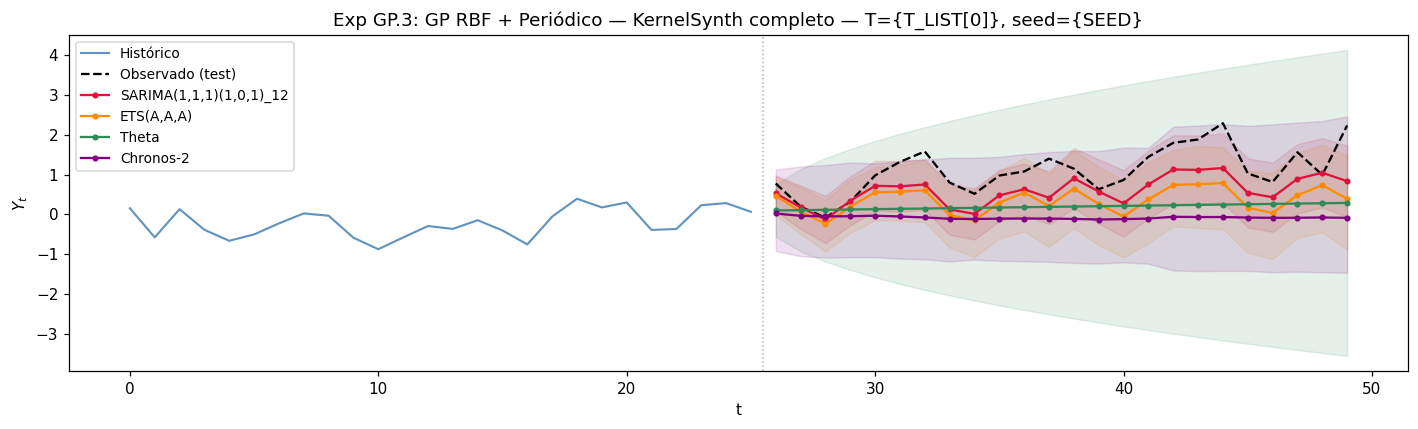

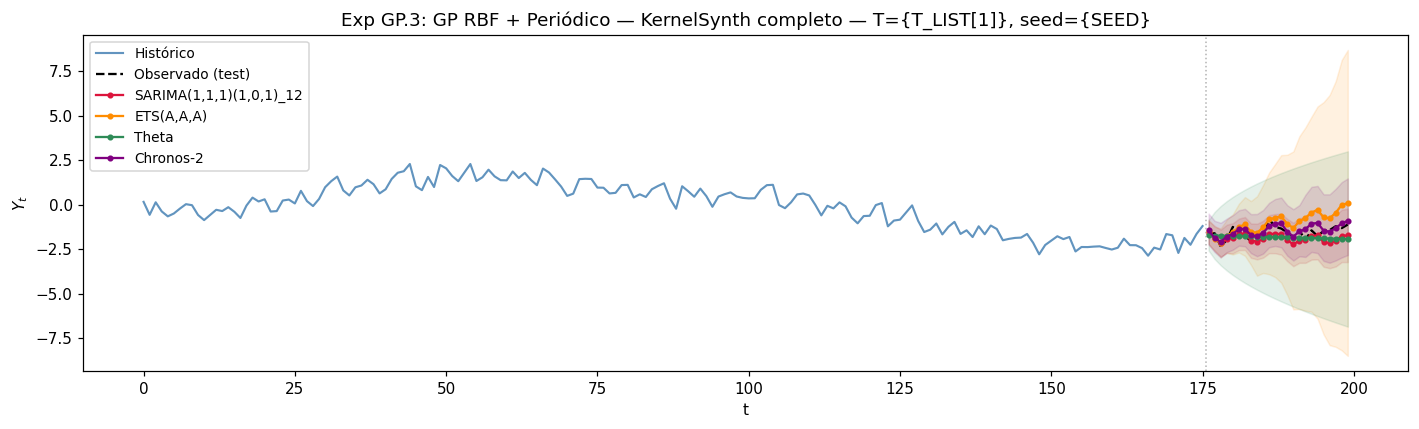

Tabla de métricas — Exp GP.3


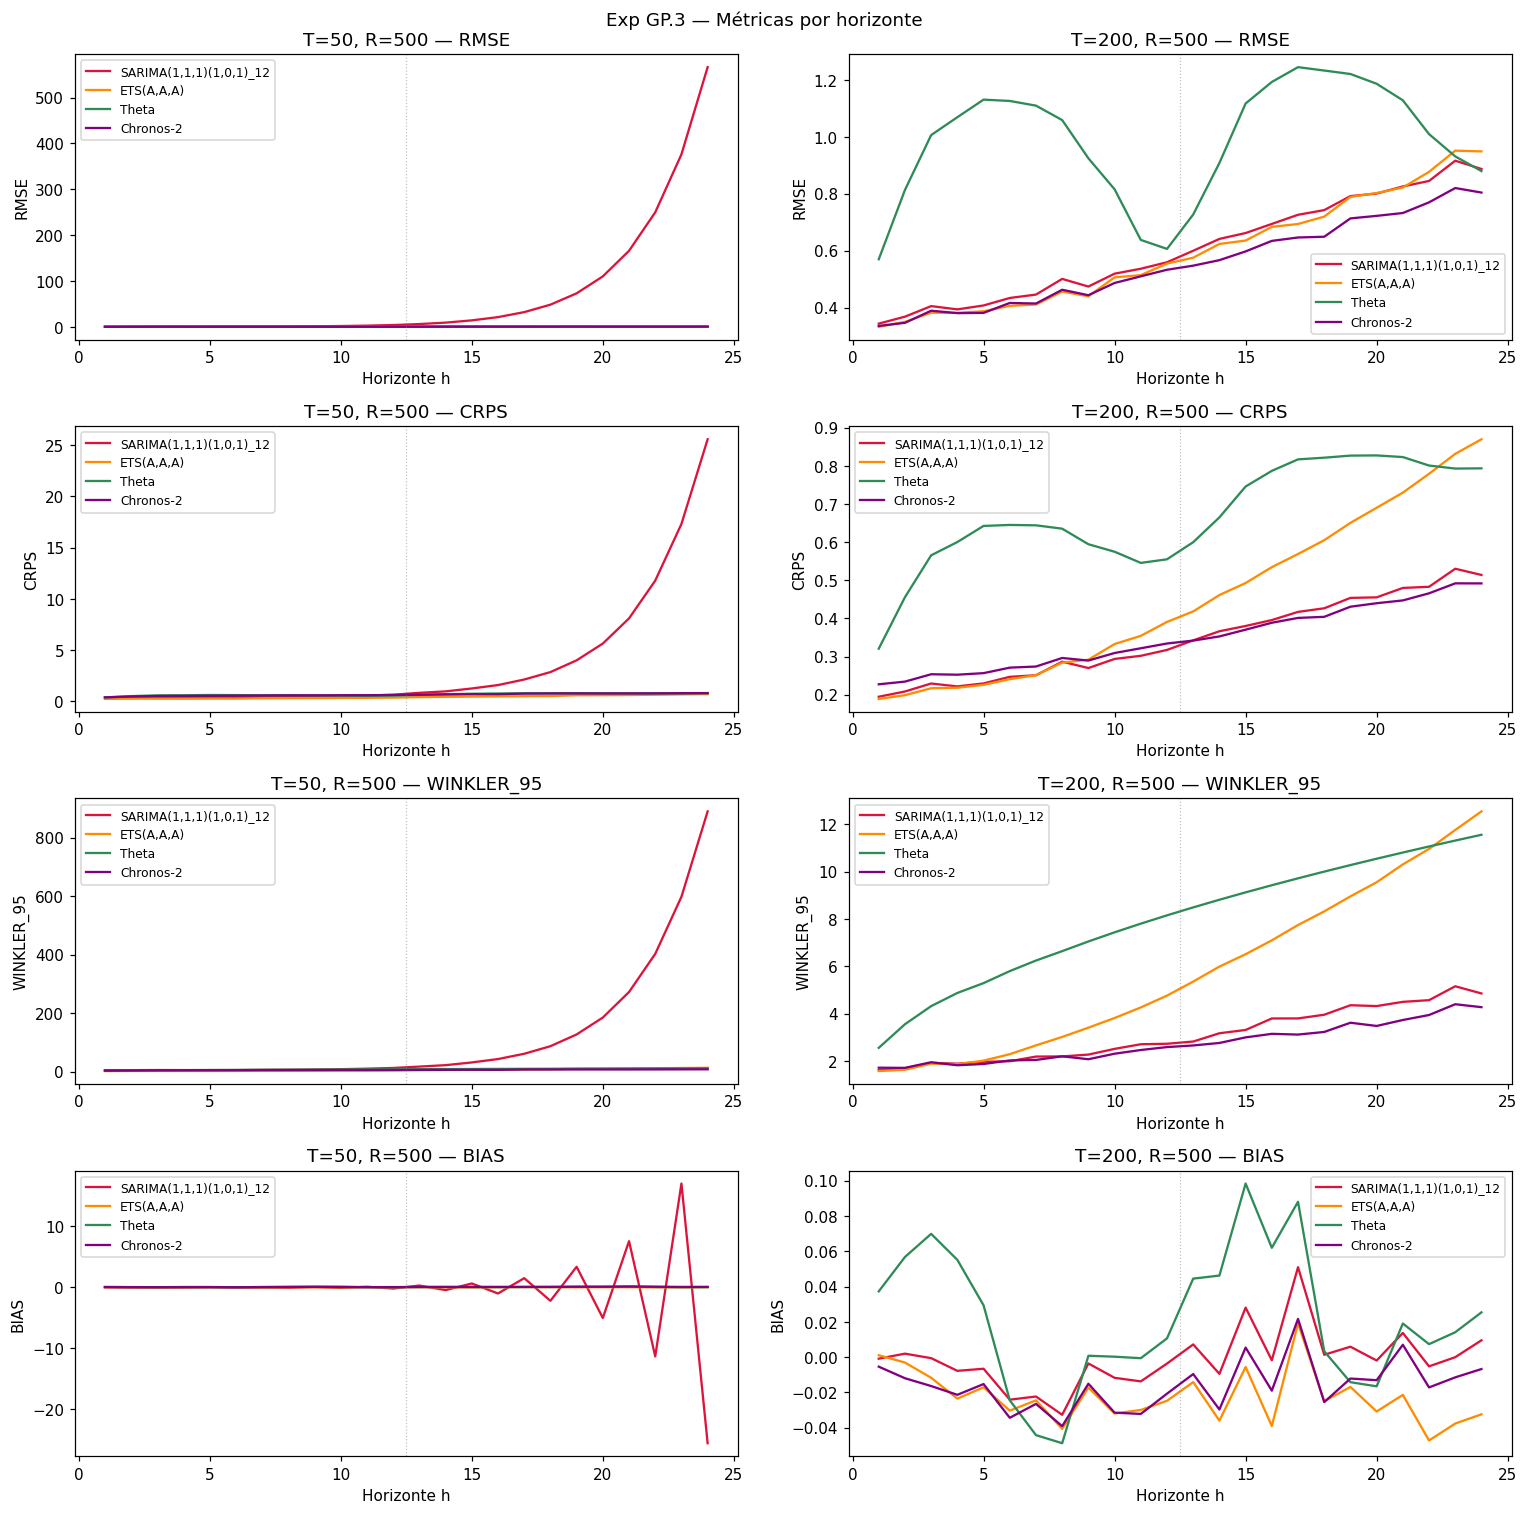

In [8]:
plot_rep(
    dgp_GP_3, make_models_GP_3, dgp_params_GP_3,
    T=T_LIST[0],
    title='Exp GP.3: GP RBF + Periódico — KernelSynth completo — T={T_LIST[0]}, seed={SEED}'
)
plot_rep(
    dgp_GP_3, make_models_GP_3, dgp_params_GP_3,
    T=T_LIST[1],
    title='Exp GP.3: GP RBF + Periódico — KernelSynth completo — T={T_LIST[1]}, seed={SEED}'
)
print("Tabla de métricas — Exp GP.3")
results_table(results_GP_3)
plot_metrics(
    results_GP_3,
    title="Exp GP.3 — Métricas por horizonte",
    metrics=("rmse", "crps", "winkler_95", "bias")
)